In [1]:
!pip install pandas numpy scikit-learn pdfplumber python-docx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 91.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import pdfplumber
import docx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
resumes = {
    "Alice": "Python developer with machine learning, pandas, numpy, SQL and data analysis experience.",
    "Bob": "Java backend developer with Spring Boot, Microservices, MySQL and API development experience.",
    "Charlie": "Data scientist with Python, TensorFlow, NLP, deep learning and AI projects."
}

In [4]:
job_description = """
We are looking for a Python developer with skills in:
machine learning, pandas, numpy, SQL, and data analysis.
Knowledge of AI or NLP is a plus.
"""

In [5]:
names = list(resumes.keys())
texts = list(resumes.values())

texts.append(job_description)  # add job description at end

In [6]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(texts)

In [7]:
job_vector = tfidf_matrix[-1]
resume_vectors = tfidf_matrix[:-1]

scores = cosine_similarity(resume_vectors, job_vector).flatten()

In [8]:
results = pd.DataFrame({
    "Candidate": names,
    "Score": scores
})

In [9]:
results = results.sort_values(by="Score", ascending=False)
results

,Candidate,Score
0,Alice,0.647778
2,Charlie,0.306909
1,Bob,0.042917


In [10]:
threshold = 0.2

results["Status"] = results["Score"].apply(
    lambda x: "Shortlisted" if x >= threshold else "Rejected"
)

results

,Candidate,Score,Status
0,Alice,0.647778,Shortlisted
2,Charlie,0.306909,Shortlisted
1,Bob,0.042917,Rejected


In [11]:
results.to_csv("resume_screening_output.csv", index=False)
print("CSV file created successfully!")

CSV file created successfully!


In [12]:
from google.colab import files
files.download("resume_screening_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

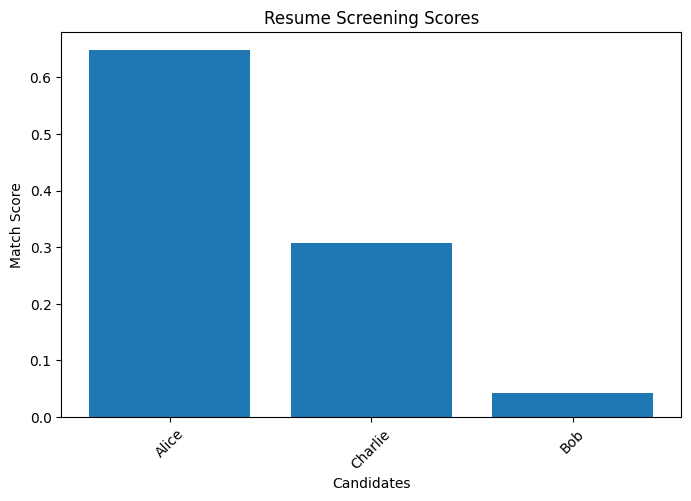

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Candidate"], results["Score"])

plt.title("Resume Screening Scores")
plt.xlabel("Candidates")
plt.ylabel("Match Score")

plt.xticks(rotation=45)

plt.show()

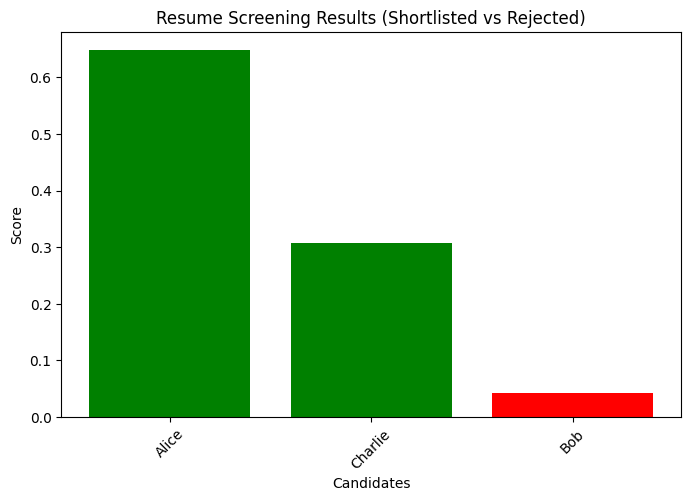

In [14]:
colors = results["Status"].map({
    "Shortlisted": "green",
    "Rejected": "red"
})

plt.figure(figsize=(8,5))
plt.bar(results["Candidate"], results["Score"], color=colors)

plt.title("Resume Screening Results (Shortlisted vs Rejected)")
plt.xlabel("Candidates")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()

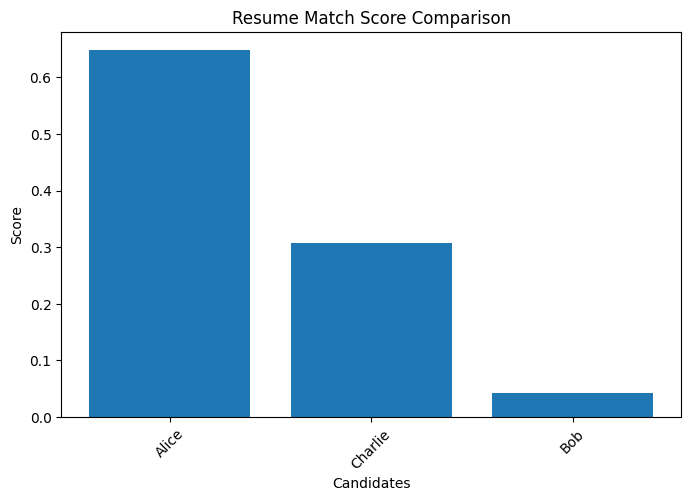

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Candidate"], results["Score"])

plt.title("Resume Match Score Comparison")
plt.xlabel("Candidates")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.show()

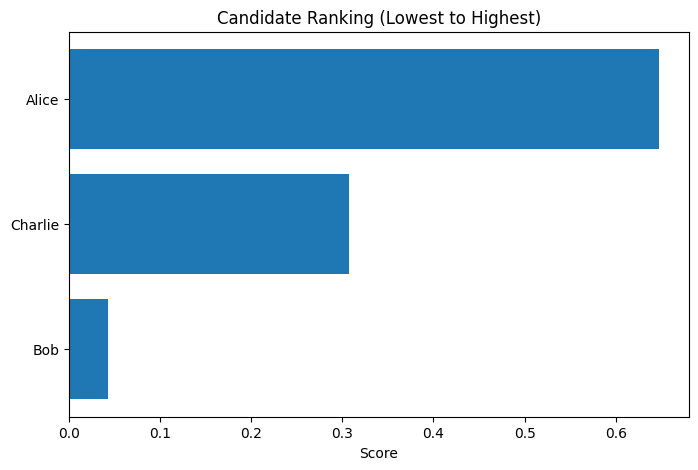

In [16]:
sorted_results = results.sort_values("Score")

plt.figure(figsize=(8,5))
plt.barh(sorted_results["Candidate"], sorted_results["Score"])

plt.title("Candidate Ranking (Lowest to Highest)")
plt.xlabel("Score")

plt.show()

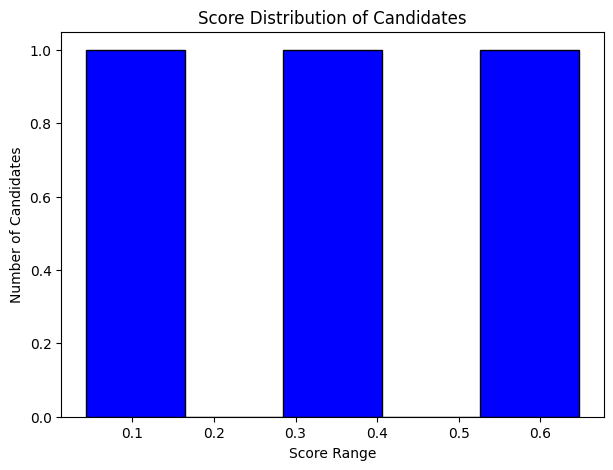

In [17]:
plt.figure(figsize=(7,5))
plt.hist(results["Score"], bins=5, color="blue", edgecolor="black")

plt.title("Score Distribution of Candidates")
plt.xlabel("Score Range")
plt.ylabel("Number of Candidates")

plt.show()